
# Concrete Crack Detection (Semantic Segmentation)

This notebook demonstrates how to train a YOLO26 model for detecting concrete cracks, evaluate its performance, and deploy it as a Gradio web application.



## Install Ultralytics

First, we need to install the `ultralytics` library, which provides the YOLO (You Only Look Once) model functionalities. The `-q` flag ensures a quiet installation.


In [1]:
!pip install -q ultralytics


## Download Dataset

Next, we download the dataset for training the crack detection model from Kaggle Hub. The dataset used is "roads-and-bridges-cracks-yolov8-format". The `path` variable will store the location of the downloaded dataset.


In [4]:
import kagglehub
import os

path = kagglehub.dataset_download("rukiyeaydn/road-crack-dataset")
dataset_root = os.path.join(path, "road crack dataset semantic")
print("Dataset successfully downloaded to:", dataset_root)

Using Colab cache for faster access to the 'road-crack-dataset' dataset.
Dataset successfully downloaded to: /kaggle/input/road-crack-dataset/road crack dataset semantic


## Directory Structure Inspection

This function recursively scans and displays a directory tree starting from a given target path, making it easy to inspect complex dataset structures (like Kaggle downloads).

**Key Features:**
* **Depth Control:** Limits folder traversal depth (`max_depth=3`) to prevent overwhelming output on deeply nested structures.
* **Output Truncation:** Displays up to **3 files per folder**; if a directory contains more, it displays a summary count (e.g., `... and N more files`).
* **Path Validation:** Checks whether the specified directory exists before attempting to traverse.

In [5]:
import os

def print_directory_tree(startpath, max_depth=3):
    print(f"Checking directory structure for: {startpath}\n")
    if not os.path.exists(startpath):
        print("Path does not exist!")
        return

    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        if level >= max_depth:
            continue
        indent = ' ' * 4 * (level)
        print(f"{indent}📁 {os.path.basename(root)}/")
        subindent = ' ' * 4 * (level + 1)

        # Show first 3 files in the folder to keep it clean
        for f in files[:3]:
            print(f"{subindent}📄 {f}")
        if len(files) > 3:
            print(f"{subindent}📄 ... and {len(files) - 3} more files")

# Scan the Kaggle download root directory
print_directory_tree(path)

Checking directory structure for: /kaggle/input/road-crack-dataset

📁 road-crack-dataset/
    📄 README.md
    📁 road crack dataset semantic/
        📁 valid/
            📄 road_1041_6_jpg.rf.3ecf39925e0966993a03c2edb50d59d6.jpg
            📄 road_1043_6_jpg.rf.3bd8098099d3c9733cf3e745832aa773.jpg
            📄 road_1041_2_jpg.rf.3676e8be6f216537f49e39f98098e794_mask.png
            📄 ... and 171 more files
        📁 train/
            📄 road_1001_2_jpg.rf.652c417741410e0fdf2e8547b6c68fe0.jpg
            📄 road_1031_2_jpg.rf.a20f9dd0af2b55508b4861831be943be.jpg
            📄 road_1041_1_jpg.rf.c7df8fbf42fdfdf8958002d1b9e93993_mask.png
            📄 ... and 693 more files


## YOLO Dataset Preparation & Format Conversion

This step converts a read-only semantic segmentation dataset (binary masks) into a writable, native **YOLO Segmentation** format (`.txt` polygon coordinates).

### Workflow Overview:
1. **Environment Setup:** Creates a writable working directory at `/content/crack_dataset/`.
2. **Mask-to-Polygon Extraction:**
   * Reads target mask images (`_mask.png`) in grayscale.
   * Extracts object contours using OpenCV (`cv2.findContours`).
   * Normalizes pixel coordinates relative to image width and height.
   * Saves polygon coordinates to `.txt` label files (`class_id x1 y1 x2 y2 ...`).
3. **Symlinking Images:** Creates soft links (`os.symlink`) to original images to save time and storage space.
4. **Configuration Generation:** Automatically builds the dataset metadata file (`data.yaml`) required for YOLO model training.

In [6]:
import os
import cv2
import yaml
from pathlib import Path

# Source dataset paths (Read-Only Kaggle Mount)
src_dataset_root = os.path.join(path, "road crack dataset semantic")

# Setup standard writable directories inside Colab's local space
writable_root = "/content/crack_dataset"
os.makedirs(writable_root, exist_ok=True)

def setup_yolo_split(split_name):
    # Establish local clean directories side-by-side as YOLO expects
    images_dst = os.path.join(writable_root, split_name, "images")
    labels_dst = os.path.join(writable_root, split_name, "labels")
    os.makedirs(images_dst, exist_ok=True)
    os.makedirs(labels_dst, exist_ok=True)

    # Source directory containing both images and masks mixed together
    split_src_dir = os.path.join(src_dataset_root, split_name)

    if not os.path.exists(split_src_dir):
        print(f"Directory {split_src_dir} does not exist!")
        return

    print(f"Processing split '{split_name}'...")

    # Loop over the files in the flat directory
    for file_name in os.listdir(split_src_dir):
        # Handle Mask Images
        if file_name.endswith('_mask.png'):
            mask_path = os.path.join(split_src_dir, file_name)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if mask is None:
                continue

            contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            # Match mask filename back to its corresponding image name
            img_base_name = file_name.replace('_mask.png', '.jpg')
            label_path = os.path.join(labels_dst, img_base_name.replace('.jpg', '.txt'))

            h, w = mask.shape
            with open(label_path, 'w') as f:
                for contour in contours:
                    if len(contour) < 3:
                        continue
                    contour = contour.reshape(-1, 2)
                    normalized = [f"{x / w:.6f} {y / h:.6f}" for x, y in contour]
                    f.write(f"0 {' '.join(normalized)}\n")

        # Handle Normal Images (skip masks)
        elif file_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            src_img_path = os.path.join(split_src_dir, file_name)
            dst_img_path = os.path.join(images_dst, file_name)
            if not os.path.exists(dst_img_path):
                os.symlink(src_img_path, dst_img_path)

# Restructure train and valid splits smoothly
setup_yolo_split("train")
setup_yolo_split("valid")

# Write a pristine, native YOLO configuration file targeting our new folders
yaml_path = os.path.join(writable_root, "data.yaml")
data_yaml_content = {
    'path': writable_root,
    'train': 'train/images',
    'val': 'valid/images',
    'names': {
        0: 'Concrete Crack',
        1: 'Construction Joints',
        2: 'Drilling'
    }
}

with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml_content, f, default_flow_style=False)

print(f"\nRestructuring complete! Native configuration ready at: {yaml_path}")

Processing split 'train'...
Processing split 'valid'...

Restructuring complete! Native configuration ready at: /content/crack_dataset/data.yaml



## Train YOLO26 Nano Segment Model

We initialize a pre-trained `yolov26n-seg.pt` (nano version) model and then train it using our downloaded dataset. The training process is configured with 50 epochs and an image size of 640x640 pixels.


In [7]:
from ultralytics import YOLO


# load pre-trained model
model = YOLO("yolo26n-seg.pt")

# train the model
model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    task="segment",
)



New https://pypi.org/project/ultralytics/8.4.102 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.101 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/crack_dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-seg.pt, momentum=0.937, mosaic=1.

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f0faa4f6000>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 


## Export & Download Trained Model

After training, we export the `best.pt` weights of the model to the ONNX (Open Neural Network Exchange) format. ONNX is an open standard designed to represent machine learning models, which allows for easier deployment across different platforms and hardware.\
This cell provides functionality to download the exported `best.onnx` model and the pytorch model file directly to local machine. This allows us to use the trained model outside of this Colab environment.


In [8]:
from google.colab import files

# Export the trained weights to ONNX
model.export(format="onnx")

# Define the path to the best.pt file
pt_model_path = "/content/runs/segment/train-13/weights/best.pt"

# Define the path to the best.onnx file
onnx_model_path = "/content/runs/segment/train-13/weights/best.onnx"

def download_model_file(file_path, file_type):
    """Helper function to download a specified model file."""
    try:
        files.download(file_path)
        print(f"Downloading {file_path} ({file_type}).")
    except Exception as e:
        print(f"Error downloading the {file_type} model from {file_path}: {e}")
        print(f"Please ensure the {file_type} file path is correct and the file exists.")

# Download the .pt file
download_model_file(pt_model_path, ".pt")

# Download the .onnx file
download_model_file(onnx_model_path, ".onnx")

Ultralytics 8.4.101 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO26n-seg summary (fused): 139 layers, 2,689,469 parameters, 0 gradients, 9.0 GFLOPs

PyTorch: starting from '/content/runs/segment/train-13/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) ((1, 300, 38), (1, 32, 160, 160)) (6.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 408ms
Prepared 4 packages in 2.21s
Installed 4 packages in 406ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.27.0
 + onnxslim==0.1.94

requirements: AutoUpdate success ✅ 3.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0

/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 20 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 5.9s, saved as '/content/runs/segment/train-13/weights/best.onnx' (10.6 MB)

Export complete (6.5s)
Results saved to /content/runs/segment/train-13/weights/best.onnx
Predict:         yolo predict task=segment model=/content/runs/segment/train-13/weights/best.onnx imgsz=640 
Validate:        yolo val task=segment model=/content/runs/segment/train-13/weights/best.onnx imgsz=640 data=/content/crack_dataset/data.yaml  
Visualize:       https://netron.app


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


## Visualize Training Results

During training, Ultralytics generates various plots to visualize the model's performance and training progress. This section displays key evaluation plots like `results.png` (showing loss and mAP over epochs), `confusion_matrix.png`, and `F1_curve.png`.


In [10]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Path to the results directory (based on your logs: train-3)
results_dir = '/content/runs/detect/train-3'

# List of evaluation plots to view
plots = ['results.png', 'confusion_matrix.png', 'F1_curve.png']

for plot in plots:
    plot_path = os.path.join(results_dir, plot)
    if os.path.exists(plot_path):
        plt.figure(figsize=(10, 8))
        img = mpimg.imread(plot_path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(plot)
        plt.show()


## Validate Model Performance

This cell performs a final validation of the trained model using the `best.pt` weights and the validation split of the dataset. It prints important metrics such as mAP50 (mean Average Precision at an IoU threshold of 0.5) and mAP50-95 (mean Average Precision across IoU thresholds from 0.5 to 0.95), which are standard metrics for object detection tasks.


In [13]:
# Validate the model using the best weights generated
metrics = model.val(data=yaml_path)

# Print key metrics cleanly
print(f"Box mAP50: {metrics.box.map50:.4f}")
print(f"Mask mAP50: {metrics.seg.map50:.4f}")

Ultralytics 8.4.101 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 150.1±83.6 MB/s, size: 92.3 KB)
val: Scanning /content/crack_dataset/valid/labels.cache... 87 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 87/87 26.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.1s/it 6.4s
                   all         87        336      0.617      0.384      0.433      0.229      0.361      0.229      0.184     0.0545
        Concrete Crack         87        336      0.617      0.384      0.433      0.229      0.361      0.229      0.184     0.0545
Speed: 9.4ms preprocess, 10.0ms inference, 0.0ms loss, 5.3ms postprocess per image
Results saved to /content/runs/segment/val-3
Box mAP50: 0.4326
Mask mAP50: 0.1838



## Deploy with Gradio UI

Finally, we create a simple web interface using `Gradio` to interact with our trained crack detection model. You can upload an image, adjust the confidence threshold, and the application will display the image with detected cracks and a status message.

In [16]:
import gradio as gr
from ultralytics import YOLO
import cv2

# 1. Load your freshly trained custom segmentation model weights
model_path = "/content/runs/segment/train-13/weights/best.pt"
model = YOLO(model_path)


def predict_cracks(image):
    if image is None:
        return None, "Please upload an image."

    results = model(image)
    result = results[0]

    if result.masks is not None and len(result.masks) > 0:
        # FIXED: boxes=False hides the rectangular bounding box contours
        # FIXED: labels=False removes the 'Concrete Crack 0.XX' text overlays
        annotated_img = result.plot(boxes=False, labels=False)

        crack_count = len(result.masks)
        status_text = f"Success: Detected {crack_count} concrete crack segments!"

        annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
        return annotated_img, status_text
    else:
        return image, "Status: No concrete cracks detected in this sample."


# 2. Build the Segment-specific Gradio Interface
interface = gr.Interface(
    fn=predict_cracks,
    inputs=gr.Image(type="numpy", label="Upload Concrete Image"),
    outputs=[
        gr.Image(type="numpy", label="Semantic Segmentation Output"),
        gr.Textbox(label="Detection Status")
    ],
    title="Concrete Crack Detection UI (Semantic Segmentation)",
    description="Upload a concrete surface photo. The custom YOLO model will overlay precise pixel masks over any detected cracks or defects.",
    theme="interactive"
)

# Launch the app with a public share link
interface.launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:171: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  super().__init__(
/usr/local/lib/python3.12/dist-packages/gradio/utils.py:583: UserWarning: Cannot load interactive. Caught Exception: Client error '404 Not Found' for url 'https://huggingface.co/api/spaces/interactive' (Request ID: Root=1-6a5cd4c0-0c0acc6341f345cd2fb94d81;b380c18a-01a3-4da4-b99c-3e310e1613d0)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/404

Sorry, we can't find the page you are looking for.
  warnings.warn(f"Cannot load {theme}. Caught Exception: {str(e)}")


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://586fdffa269ed17236.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Model Output 1

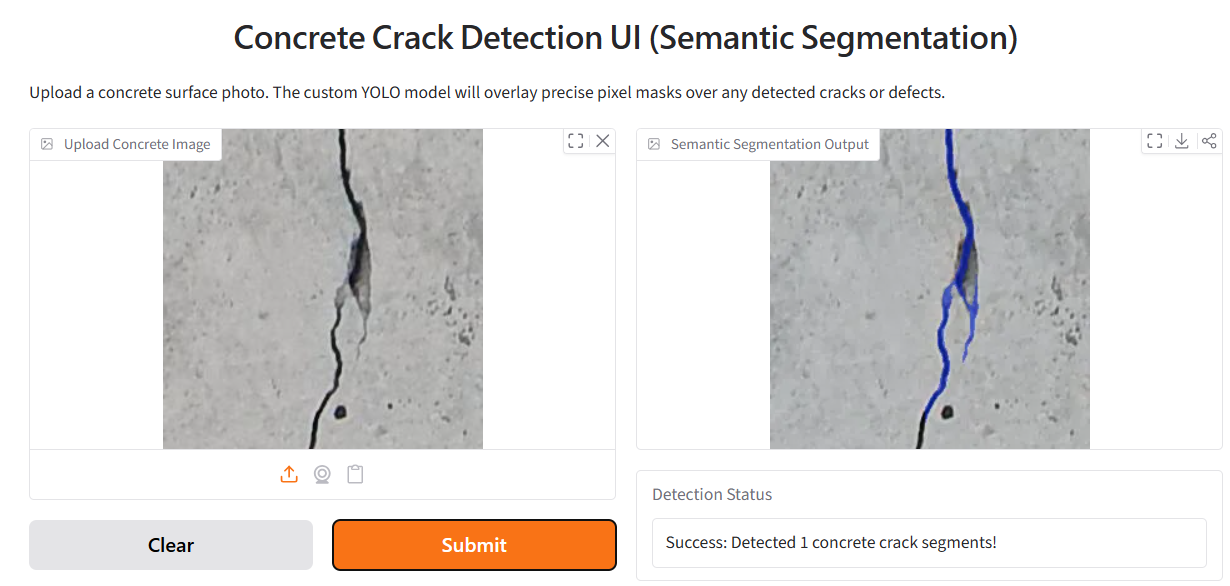

## Model Output 2

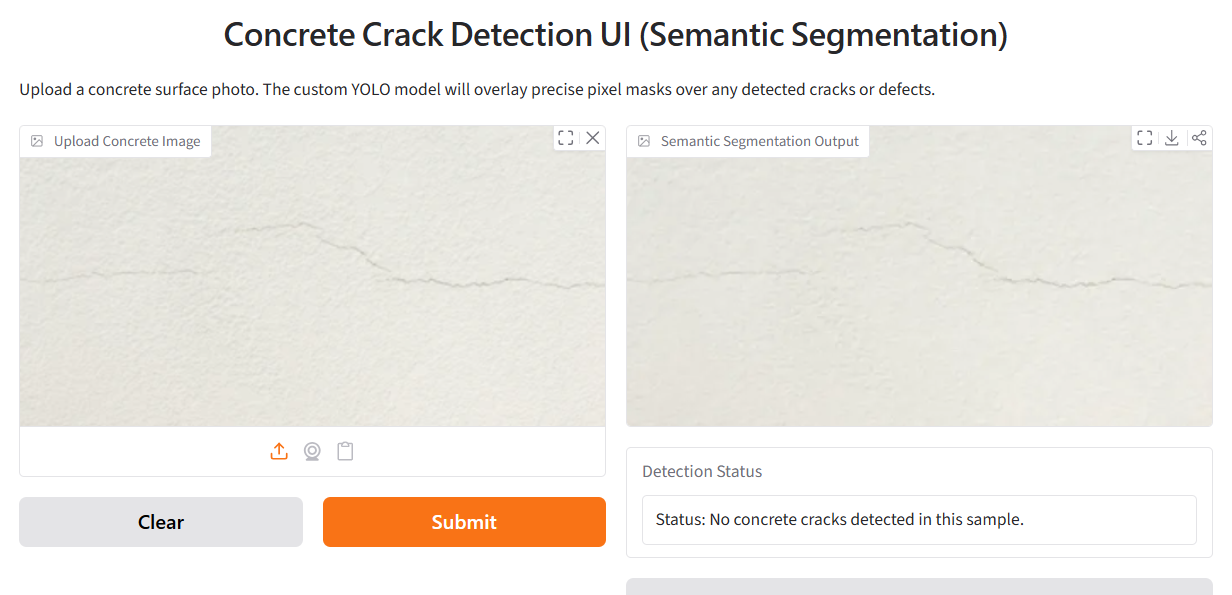

## Model Output 3

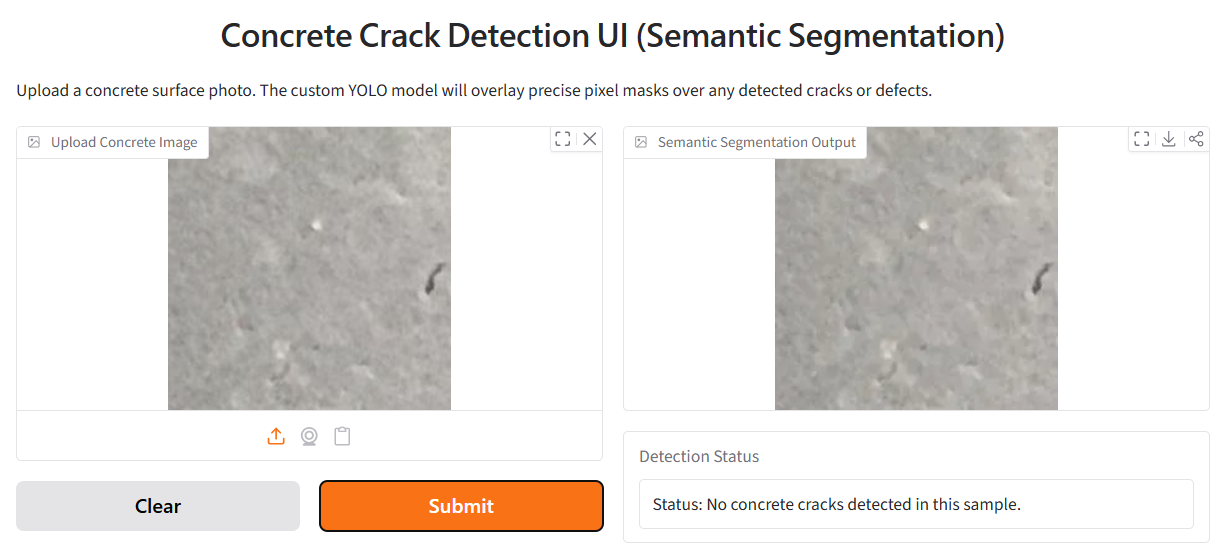